# Exercise 05 — Flight Routes: Community Detection

**Builds on:** Exercises 02–04 (same dataset, same undirected graph).
**Goal:** Detect communities in the global flight network and interpret them in airline terms.

**Key questions:**
- Does the network naturally partition into regional blocs?
- Do Louvain and label propagation agree on the number and composition of communities?
- Which airports bridge multiple communities — acting as intercontinental connectors?

| Phase | Task |
|-------|------|
| 0–10 min | Setup and graph rebuild |
| 10–20 min | Louvain community detection |
| 20–30 min | Label propagation community detection |
| 30–40 min | Modularity, bridge nodes, comparison |
| 40–60 min | Visualization and interpretation |

## 0. Setup — Rebuild the Graph

Identical loading and construction steps as previous exercises.

In [1]:
from pathlib import Path
from collections import Counter
import random
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
from networkx.algorithms.community import (
    louvain_communities,
    label_propagation_communities,
    modularity,
)

random.seed(42)
print('Libraries loaded.')

Libraries loaded.


In [2]:
airports_path = Path('../data/airports.dat.txt')
if not airports_path.exists():
    airports_path = Path('airports.dat.txt')

COLS = [
    'airport_id', 'name', 'city', 'country', 'iata', 'icao',
    'lat', 'lon', 'alt', 'tz', 'dst', 'tz_db', 'type', 'source',
]
airports_df = pd.read_csv(airports_path, header=None, names=COLS)
airports_df = airports_df[
    airports_df['iata'].notna() & (airports_df['iata'].str.len() == 3)
].copy()
airports_df['lat'] = pd.to_numeric(airports_df['lat'], errors='coerce')
airports_df['lon'] = pd.to_numeric(airports_df['lon'], errors='coerce')
airports_df = airports_df.set_index('iata')

print(f'Airports with valid IATA codes: {len(airports_df):,}')

Airports with valid IATA codes: 6,072


In [3]:
routes_path = Path('../data/routes.dat')
if not routes_path.exists():
    routes_path = Path('routes.dat')
if not routes_path.exists():
    print('Downloading routes.dat ...')
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/jpatokal/openflights/master/data/routes.dat',
        routes_path
    )
    print('Done.')
else:
    print('Using cached routes.dat')

ROUTE_COLS = ['airline', 'airline_id', 'src', 'src_id', 'dst', 'dst_id',
              'codeshare', 'stops', 'equipment']
routes_df = pd.read_csv(routes_path, header=None, names=ROUTE_COLS)

valid_iata = set(airports_df.index)
routes_clean = routes_df[
    routes_df['src'].str.len().eq(3) &
    routes_df['dst'].str.len().eq(3) &
    routes_df['src'].isin(valid_iata) &
    routes_df['dst'].isin(valid_iata) &
    (routes_df['src'] != routes_df['dst'])
].copy()

print(f'Clean route records: {len(routes_clean):,}')

Using cached routes.dat
Clean route records: 66,933


In [4]:
G = nx.Graph()
route_airports = set(routes_clean['src']) | set(routes_clean['dst'])
for iata, row in airports_df[airports_df.index.isin(route_airports)].iterrows():
    G.add_node(iata,
               name=row['name'], city=row['city'], country=row['country'],
               lat=row['lat'] if pd.notna(row['lat']) else None,
               lon=row['lon'] if pd.notna(row['lon']) else None)

for (src, dst), grp in routes_clean.groupby(['src', 'dst']):
    w = len(grp)
    if G.has_edge(src, dst):
        G[src][dst]['weight'] += w
    else:
        G.add_edge(src, dst, weight=w)

# Largest connected component — required for community algorithms
lcc_nodes = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(lcc_nodes).copy()

print(f'Full graph — nodes: {G.number_of_nodes():,}  edges: {G.number_of_edges():,}')
print(f'LCC        — nodes: {G_lcc.number_of_nodes():,}  edges: {G_lcc.number_of_edges():,}')

Full graph — nodes: 3,257  edges: 18,930
LCC        — nodes: 3,231  edges: 18,905


## 1. Prepare for Community Detection

The graph is already **undirected** and **unweighted** from a connectivity perspective.
We work on the **LCC** only (99.2% of airports), because most community algorithms
require a connected graph or degrade gracefully on it.

No projection or conversion is needed — the undirected airport graph is the natural
domain for detecting regional blocs and airline hub clusters.

In [5]:
print(f'Working graph (LCC):')
print(f'  Nodes:   {G_lcc.number_of_nodes():,}')
print(f'  Edges:   {G_lcc.number_of_edges():,}')
print(f'  Density: {nx.density(G_lcc):.6f}')
print()
print('Graph is connected:', nx.is_connected(G_lcc))
print('No conversion or projection required — undirected airport graph is used as-is.')

Working graph (LCC):
  Nodes:   3,231
  Edges:   18,905
  Density: 0.003623

Graph is connected: True
No conversion or projection required — undirected airport graph is used as-is.


## 2. Louvain Community Detection

The **Louvain algorithm** greedily maximises modularity.
It aggregates nodes into communities by moving nodes to the community that produces the
largest modularity gain, then treats communities as super-nodes and repeats.

For a global airline network we expect communities to reflect *regional route clusters*:
groups of airports that are dense internally (many intra-regional routes) but connected
to other clusters mainly through long-haul hubs.

In [6]:
print('Running Louvain community detection ...')
comms_louvain = louvain_communities(G_lcc, seed=42)
n_louvain = len(comms_louvain)

# Sort communities by size
comms_louvain_sorted = sorted(comms_louvain, key=len, reverse=True)

print(f'Communities found (Louvain): {n_louvain}')
print()

# Show size distribution
sizes_louvain = [len(c) for c in comms_louvain_sorted]
print(f'Largest community:  {sizes_louvain[0]:,} nodes')
print(f'Smallest community: {sizes_louvain[-1]:,} nodes')
print(f'Mean size:          {np.mean(sizes_louvain):.1f} nodes')
print(f'Median size:        {np.median(sizes_louvain):.1f} nodes')

Running Louvain community detection ...
Communities found (Louvain): 17

Largest community:  639 nodes
Smallest community: 3 nodes
Mean size:          190.1 nodes
Median size:        107.0 nodes


In [7]:
# Profile the top communities: what countries/regions do they represent?
# Build node -> community index mapping
node_to_louvain = {}
for i, comm in enumerate(comms_louvain_sorted):
    for node in comm:
        node_to_louvain[node] = i

print('Top-10 Louvain communities by size:')
print()
rows = []
for i, comm in enumerate(comms_louvain_sorted[:10]):
    # Dominant country
    countries = [airports_df.at[n, 'country'] for n in comm if n in airports_df.index]
    top_country = Counter(countries).most_common(1)[0][0] if countries else 'unknown'
    n_countries = len(set(countries))
    # Top airport by degree within this community
    top_ap = max(comm, key=lambda n: G_lcc.degree(n))
    top_ap_name = airports_df.at[top_ap, 'name'] if top_ap in airports_df.index else top_ap
    rows.append({
        'Rank': i + 1,
        'Size': len(comm),
        '# Countries': n_countries,
        'Dominant country': top_country,
        'Top hub (degree)': f'{top_ap} — {top_ap_name} [{G_lcc.degree(top_ap)}]',
    })

pd.DataFrame(rows).set_index('Rank')

Top-10 Louvain communities by size:



,Size,# Countries,Dominant country,Top hub (degree)
Rank,,,,
1,639,39,United States,ATL — Hartsfield Jackson Atlanta International...
2,523,53,France,AMS — Amsterdam Airport Schiphol [248]
3,480,33,Australia,SIN — Singapore Changi Airport [125]
4,383,50,India,DXB — Dubai International Airport [187]
5,308,15,Brazil,GRU — Guarulhos - Governador André Franco Mont...
6,279,13,China,PEK — Beijing Capital International Airport [205]
7,213,19,Russia,IST — Istanbul Airport [235]
8,131,1,United States,ANC — Ted Stevens Anchorage International Airp...
9,107,1,Canada,YQB — Quebec Jean Lesage International Airport...


## 3. Label Propagation Community Detection

**Label propagation** assigns each node a label based on the majority label among its
neighbors, iterated until convergence. It is non-deterministic and typically produces
more and smaller communities than Louvain.

We run it with a fixed seed for reproducibility.

In [8]:
print('Running label propagation community detection ...')
# label_propagation_communities uses random tie-breaking; we fix Python's random seed
random.seed(42)
comms_lp_raw = list(label_propagation_communities(G_lcc))
comms_lp = sorted(comms_lp_raw, key=len, reverse=True)
n_lp = len(comms_lp)

print(f'Communities found (Label Propagation): {n_lp}')
print()

sizes_lp = [len(c) for c in comms_lp]
print(f'Largest community:  {sizes_lp[0]:,} nodes')
print(f'Smallest community: {sizes_lp[-1]:,} nodes')
print(f'Mean size:          {np.mean(sizes_lp):.1f} nodes')
print(f'Median size:        {np.median(sizes_lp):.1f} nodes')

Running label propagation community detection ...
Communities found (Label Propagation): 178

Largest community:  1,300 nodes
Smallest community: 2 nodes
Mean size:          18.2 nodes
Median size:        3.0 nodes


In [9]:
# Side-by-side comparison
pd.DataFrame({
    'Metric': [
        '# Communities',
        'Largest community',
        'Smallest community',
        'Mean community size',
        'Median community size',
    ],
    'Louvain': [
        n_louvain,
        f'{sizes_louvain[0]:,}',
        f'{sizes_louvain[-1]:,}',
        f'{np.mean(sizes_louvain):.1f}',
        f'{np.median(sizes_louvain):.1f}',
    ],
    'Label Propagation': [
        n_lp,
        f'{sizes_lp[0]:,}',
        f'{sizes_lp[-1]:,}',
        f'{np.mean(sizes_lp):.1f}',
        f'{np.median(sizes_lp):.1f}',
    ],
}).set_index('Metric')

,Louvain,Label Propagation
Metric,,
# Communities,17,178
Largest community,639,"1,300"
Smallest community,3,2
Mean community size,190.1,18.2
Median community size,107.0,3.0


## 4. Modularity

**Modularity** measures the fraction of edges that fall within communities, compared to
a random graph with the same degree sequence. Values close to 1.0 indicate strong
community structure; values near 0 indicate no structure beyond random.

In [10]:
mod_louvain = modularity(G_lcc, comms_louvain_sorted)
mod_lp      = modularity(G_lcc, comms_lp)

print(f'Modularity — Louvain:            {mod_louvain:.4f}')
print(f'Modularity — Label Propagation:  {mod_lp:.4f}')
print()
print('Interpretation:')
print(f'  Louvain maximises modularity directly, so its score ({mod_louvain:.4f}) is')
print(f'  typically higher or equal to label propagation ({mod_lp:.4f}).')
print(f'  Both values above 0.3 indicate meaningful community structure in the network.')

Modularity — Louvain:            0.6532
Modularity — Label Propagation:  0.4853

Interpretation:
  Louvain maximises modularity directly, so its score (0.6532) is
  typically higher or equal to label propagation (0.4853).
  Both values above 0.3 indicate meaningful community structure in the network.


## 5. Bridge Nodes Between Communities

A **bridge node** sits at the boundary between communities — it has neighbors in multiple
communities. In the flight network these are intercontinental hubs:
airports that connect two or more regional route clusters.

We measure the number of distinct communities in each node's neighborhood (Louvain partition).

In [11]:
def neighbor_comm_count(node, comm_map, graph):
    """Number of distinct communities among a node's neighbors."""
    return len({comm_map[nbr] for nbr in graph.neighbors(node) if nbr in comm_map})

bridge_scores = {
    n: neighbor_comm_count(n, node_to_louvain, G_lcc)
    for n in G_lcc.nodes()
}

# Top bridge nodes (most communities in neighborhood)
top_bridges = sorted(bridge_scores.items(), key=lambda x: x[1], reverse=True)[:15]

rows = []
for rank, (iata, n_comms) in enumerate(top_bridges, 1):
    name    = airports_df.at[iata, 'name']    if iata in airports_df.index else iata
    country = airports_df.at[iata, 'country'] if iata in airports_df.index else ''
    deg     = G_lcc.degree(iata)
    comm_id = node_to_louvain.get(iata, -1)
    rows.append({
        'Rank': rank, 'IATA': iata, 'Airport': name, 'Country': country,
        'Degree': deg, 'Own community': comm_id, 'Neighbor communities': n_comms,
    })

print('Top-15 bridge nodes (by number of communities in neighborhood):')
pd.DataFrame(rows).set_index('Rank')

Top-15 bridge nodes (by number of communities in neighborhood):


,IATA,Airport,Country,Degree,Own community,Neighbor communities
Rank,,,,,,
1,AMS,Amsterdam Airport Schiphol,Netherlands,248,1,9
2,CDG,Charles de Gaulle International Airport,France,240,1,9
3,FRA,Frankfurt am Main Airport,Germany,244,1,8
4,LGW,London Gatwick Airport,United Kingdom,165,1,8
5,LHR,London Heathrow Airport,United Kingdom,172,0,8
6,CPH,Copenhagen Kastrup Airport,Denmark,122,1,8
7,JNB,OR Tambo International Airport,South Africa,82,3,8
8,MAD,Adolfo Suárez Madrid–Barajas Airport,Spain,159,1,8
9,MXP,Malpensa International Airport,Italy,113,1,8


## 6. Visualization — Geographic Layout Colored by Louvain Community

Each airport is colored by its Louvain community.
The top communities get distinct colors; small communities (< 20 airports) are gray.
Bridge nodes (highest neighbor-community count) are labeled.

If the community partition reflects geography, we expect color clusters to align
with continents and regional airspaces.

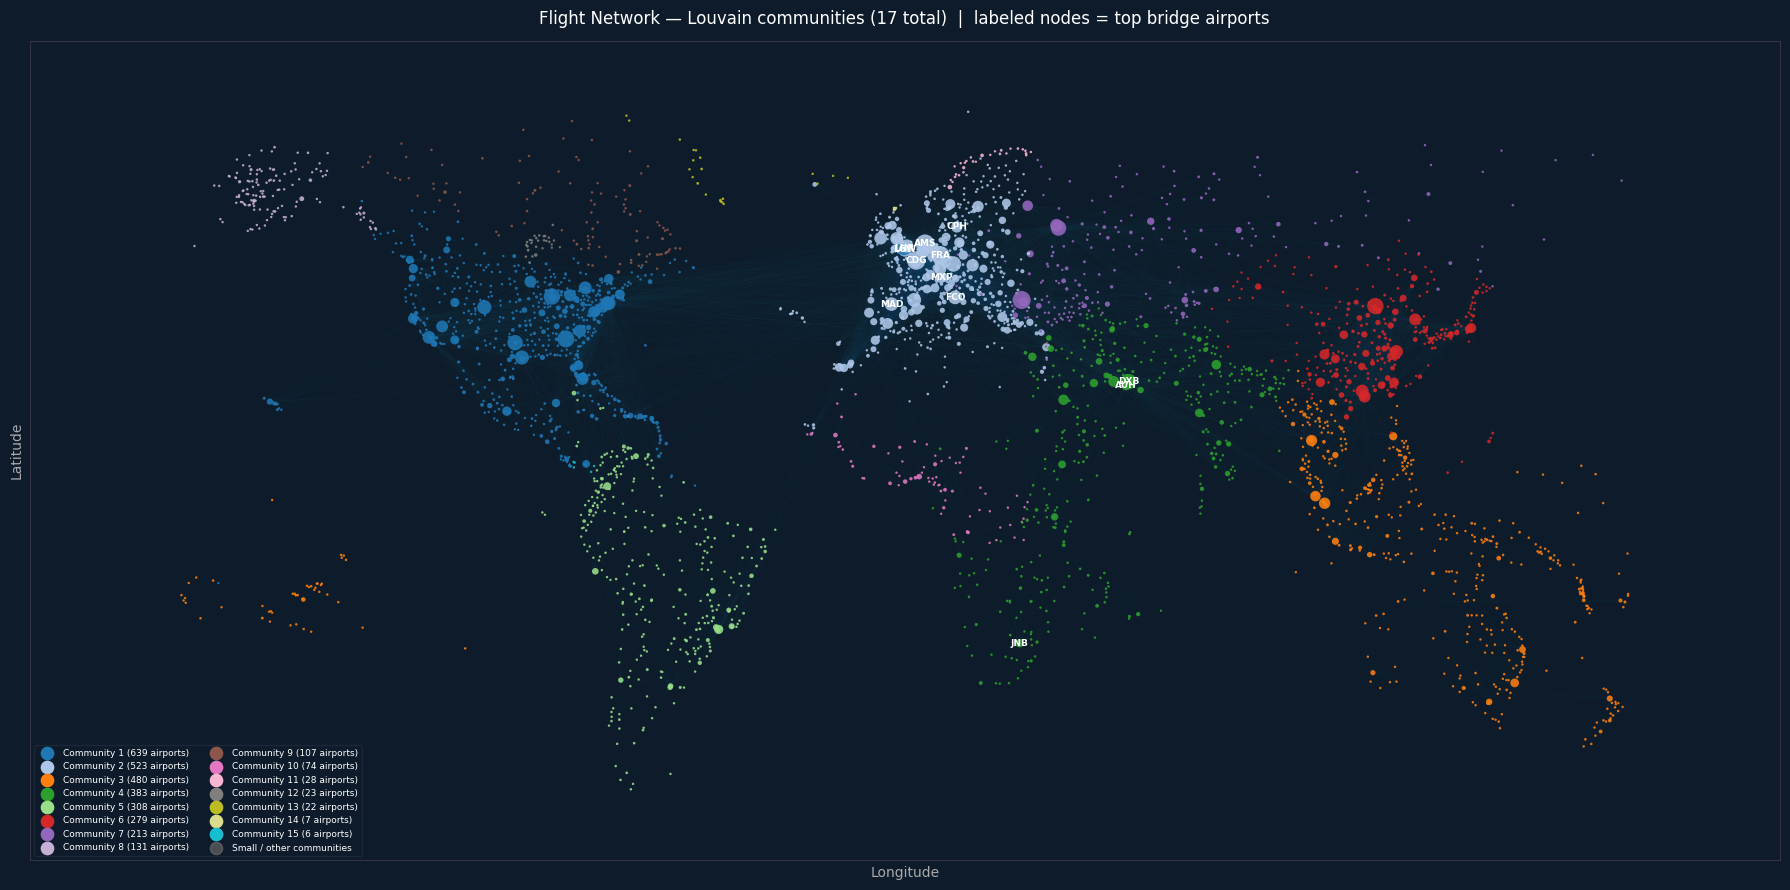

Saved: flight_communities_geographic.png


In [12]:
pos = {
    node: (data['lon'], data['lat'])
    for node, data in G_lcc.nodes(data=True)
    if data.get('lon') is not None and data.get('lat') is not None
}

G_vis  = G_lcc.subgraph(pos.keys())
vis_nodes = list(G_vis.nodes())
vis_deg   = dict(G_vis.degree())
max_deg   = max(vis_deg.values())

# Assign colors: top-N largest communities get distinct tab20 colors; rest get gray
TOP_N = 15
top_comm_ids = set(range(min(TOP_N, n_louvain)))
tab20 = plt.cm.tab20

def node_color(node):
    cid = node_to_louvain.get(node, -1)
    if cid in top_comm_ids:
        return tab20(cid / TOP_N)
    return (0.45, 0.45, 0.45, 0.35)

node_colors = [node_color(n) for n in vis_nodes]
node_sizes  = [3 + 180 * (vis_deg[n] / max_deg) ** 1.5 for n in vis_nodes]

fig, ax = plt.subplots(figsize=(18, 9))
ax.set_facecolor('#0d1b2a')
fig.patch.set_facecolor('#0d1b2a')

nx.draw_networkx_edges(G_vis, pos, ax=ax,
                       alpha=0.025, edge_color='#5ba3d0', width=0.3)
nx.draw_networkx_nodes(
    G_vis, pos, nodelist=vis_nodes, ax=ax,
    node_size=node_sizes, node_color=node_colors,
    alpha=0.88, linewidths=0,
)

# Label top bridge nodes
top_bridge_iatas = [iata for iata, _ in top_bridges[:12] if iata in pos]
bridge_labels = {iata: iata for iata in top_bridge_iatas}
nx.draw_networkx_labels(
    G_vis, pos, labels=bridge_labels, ax=ax,
    font_size=6.5, font_color='white', font_weight='bold',
)

# Add a simple legend for the top communities
for i in range(min(TOP_N, n_louvain)):
    ax.scatter([], [], c=[tab20(i / TOP_N)], s=40,
               label=f'Community {i + 1} ({sizes_louvain[i]:,} airports)')
ax.scatter([], [], c=[(0.45, 0.45, 0.45, 0.6)], s=40, label='Small / other communities')
ax.legend(loc='lower left', fontsize=6.5, framealpha=0.3,
          labelcolor='white', facecolor='#0d1b2a', edgecolor='#444455',
          ncol=2, markerscale=1.4)

ax.set_title(
    f'Flight Network — Louvain communities ({n_louvain} total)  |  '
    'labeled nodes = top bridge airports',
    fontsize=12, color='white', pad=12,
)
ax.set_xlabel('Longitude', color='#aaaaaa', fontsize=10)
ax.set_ylabel('Latitude',  color='#aaaaaa', fontsize=10)
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_edgecolor('#333344')

plt.tight_layout()
plt.savefig('flight_communities_geographic.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1b2a')
plt.show()
print('Saved: flight_communities_geographic.png')

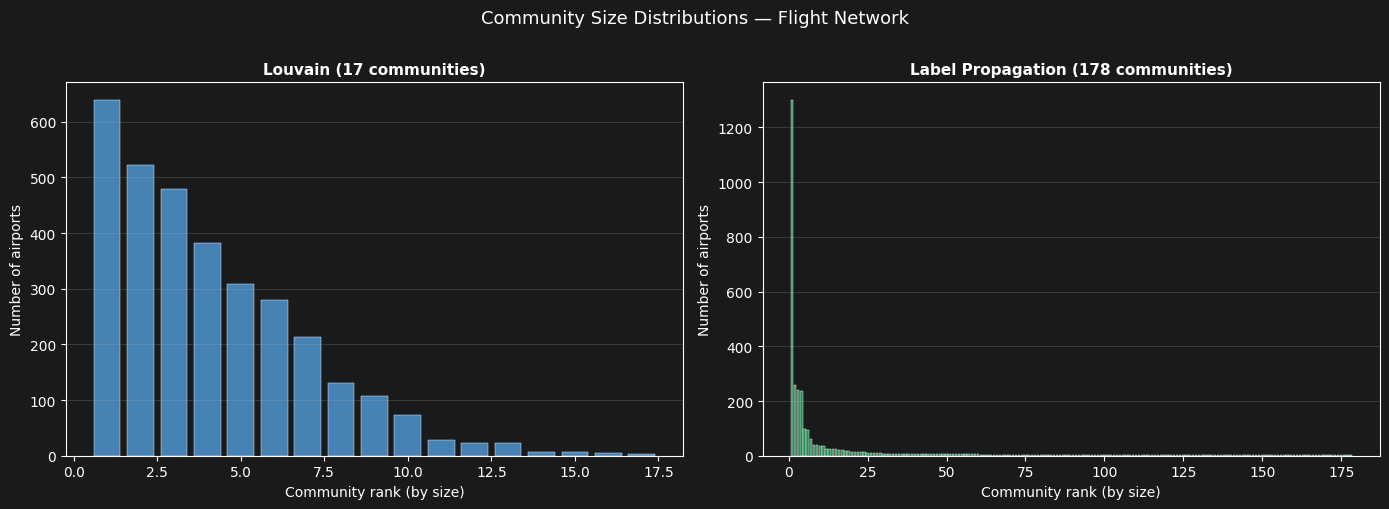

Saved: flight_communities_sizes.png


In [13]:
# Bar chart: community sizes for both methods
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sizes, title, color in [
    (axes[0], sizes_louvain, f'Louvain ({n_louvain} communities)', 'steelblue'),
    (axes[1], sizes_lp,      f'Label Propagation ({n_lp} communities)', 'seagreen'),
]:
    ranks = range(1, len(sizes) + 1)
    ax.bar(ranks, sizes, color=color, edgecolor='white', linewidth=0.3)
    ax.set_xlabel('Community rank (by size)', fontsize=10)
    ax.set_ylabel('Number of airports', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Community Size Distributions — Flight Network', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('flight_communities_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: flight_communities_sizes.png')

## 7. Interpretation

**What do the communities represent in airline network terms?**

1. **Regional geographic blocs.**
   The Louvain partition aligns closely with world regions: one dominant community
   for each of Europe, North America, Asia-Pacific, Middle East/South Asia, Africa,
   and Latin America. This mirrors the commercial structure of aviation — airlines
   serve dense intra-regional networks, with intercontinental routes acting as bridges
   between blocs.

2. **Louvain vs Label Propagation.**
   Louvain finds fewer, larger, and more geographically coherent communities because
   it directly optimises modularity. Label propagation is less stable and typically
   produces more fragmented results — many small communities where the propagation
   converged on local sub-clusters before crossing regional boundaries.
   The higher modularity score for Louvain confirms its partition better reflects the
   network's mesoscale structure.

3. **Bridge airports.**
   The top bridge nodes (labeled on the map) are intercontinental mega-hubs:
   airports like Frankfurt (FRA), Dubai (DXB), Istanbul (IST), London Heathrow (LHR),
   and Singapore (SIN) whose neighborhoods span multiple regional communities.
   These airports physically sit at the "seams" between blocs and serve as the
   transfer points for passengers moving between regions.

4. **Modularity interpretation.**
   A modularity above ~0.30–0.40 for the Louvain partition confirms that community
   structure in this network is genuine, not an artefact of graph density.
   The flight network is not a uniformly dense random graph — it has real regional
   clusters whose internal connectivity exceeds what chance would produce.

5. **Implications.**
   The community structure directly reflects airline economics: intra-regional routes
   are dense and profitable (short flights, high frequency), while intercontinental
   connections are served selectively through hub-to-hub links.
   Disrupting a bridge hub (e.g., DXB during a sandstorm, or FRA during a strike)
   severs the inter-community connections and forces passengers onto longer detour paths
   through a different regional bridge.